# Spotify Popularity Prediction

## Objective

The goal of this project is to investigate how Spotify audio features influence song popularity and to build machine learning models capable of predicting popularity scores.

The project includes:

- Exploratory Data Analysis (EDA)
- Correlation Analysis
- Hit vs Flop Comparison
- Linear Regression
- Scaled Linear Regression
- Random Forest Regression
- Streamlit Deployment

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

This dataset contains over 586,000 Spotify tracks and includes popularity scores along with audio characteristics such as:

- Danceability
- Energy
- Loudness
- Acousticness
- Instrumentalness
- Tempo
- Valence

The target variable for this project is **Popularity**.

In [3]:
df = pd.read_csv("data/tracks.csv")

## Initial Data Exploration

Before modeling, the dataset structure, size, and data types are examined to understand available features and identify potential preprocessing requirements.

In [4]:
df.shape

(586672, 20)

In [5]:
df.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  str    
 1   name              586601 non-null  str    
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  str    
 6   id_artists        586672 non-null  str    
 7   release_date      586672 non-null  str    
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          586672 non-nu

In [7]:
df.describe

<bound method NDFrame.describe of                             id                                 name  \
0       35iwgR4jXetI318WEWsa1Q                                Carve   
1       021ht4sdgPcrDgSk7JTbKY  Capítulo 2.16 - Banquero Anarquista   
2       07A5yehtSnoedViJAZkNnc   Vivo para Quererte - Remasterizado   
3       08FmqUhxtyLTn6pAh6bk45        El Prisionero - Remasterizado   
4       08y9GfoqCWfOGsKdwojr5e                  Lady of the Evening   
...                        ...                                  ...   
586667  5rgu12WBIHQtvej2MdHSH0                                  云与海   
586668  0NuWgxEp51CutD2pJoF4OM                                blind   
586669  27Y1N4Q4U3EfDU5Ubw8ws2            What They'll Say About Us   
586670  45XJsGpFTyzbzeWK8VzR8S                      A Day At A Time   
586671  5Ocn6dZ3BJFPWh4ylwFXtn                     Mar de Emociones   

        popularity  duration_ms  explicit                          artists  \
0                6       126903    

## Feature Selection

Only audio-related features were selected for modeling.

Metadata such as artist names, track IDs, and release dates were excluded because the objective was to determine how well popularity can be predicted using audio characteristics alone.

In [8]:
features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

model_df = df[features]

model_df.head()

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6,0.645,0.4450,-13.338,0.4510,0.674,0.7440,0.151,0.127,104.851,126903
1,0,0.695,0.2630,-22.136,0.9570,0.797,0.0000,0.148,0.655,102.009,98200
2,0,0.434,0.1770,-21.180,0.0512,0.994,0.0218,0.212,0.457,130.418,181640
3,0,0.321,0.0946,-27.961,0.0504,0.995,0.9180,0.104,0.397,169.980,176907
4,0,0.402,0.1580,-16.900,0.0390,0.989,0.1300,0.311,0.196,103.220,163080


## Popularity Distribution

The popularity score distribution is analyzed to understand how songs are spread across different popularity levels.

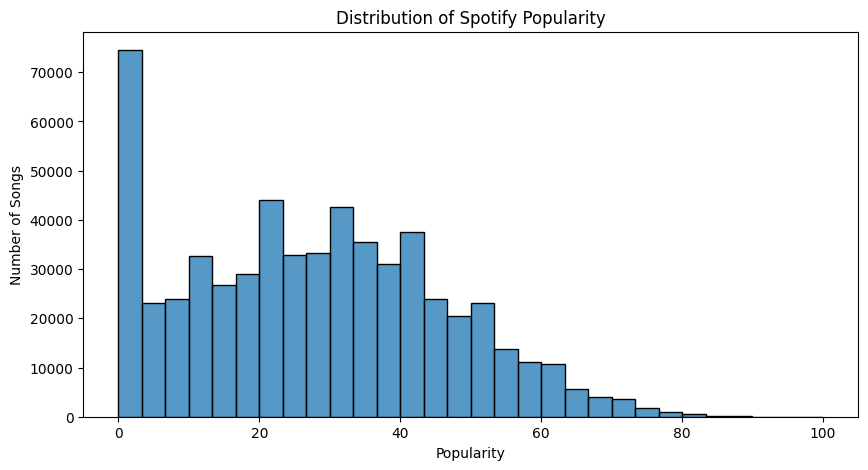

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=model_df,
    x="popularity",
    bins=30
)

plt.title("Distribution of Spotify Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

## Correlation Analysis

A correlation matrix is used to identify relationships between audio features and popularity.

This helps determine which variables may be useful predictors.

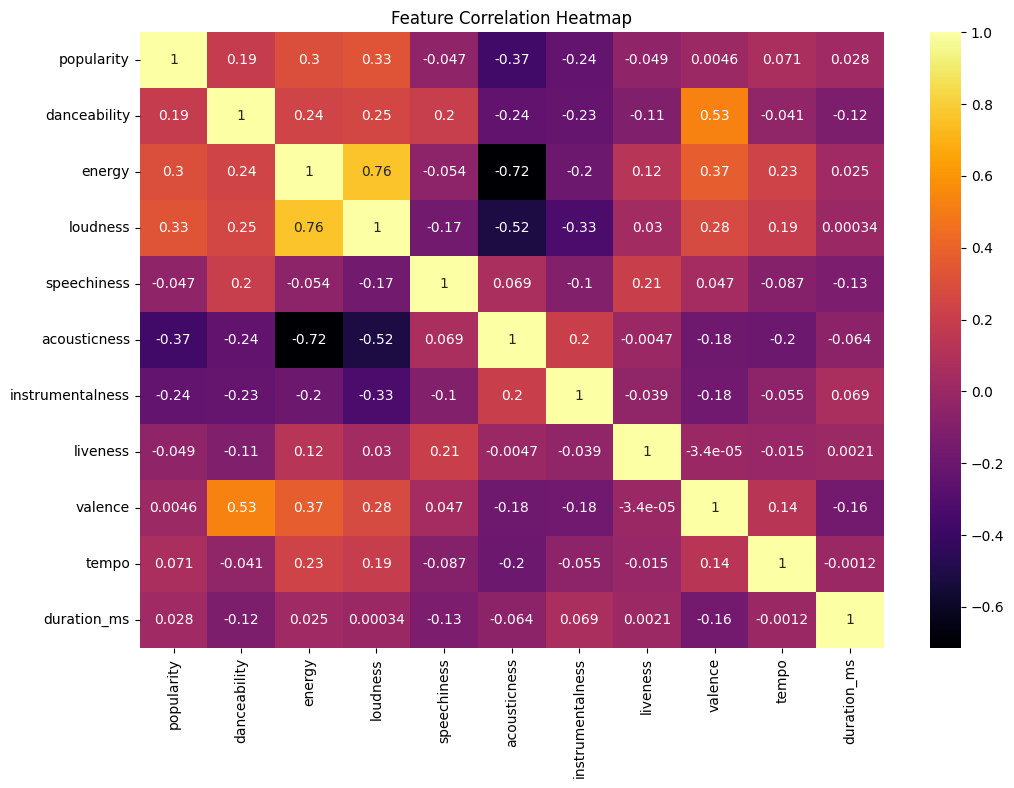

In [10]:
plt.figure(figsize=(12,8))

corr = model_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="inferno"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [11]:
corr["popularity"].sort_values(ascending=False)

popularity          1.000000
loudness            0.327028
energy              0.302315
danceability        0.187000
tempo               0.071364
duration_ms         0.027681
valence             0.004643
speechiness        -0.047357
liveness           -0.048740
instrumentalness   -0.236487
acousticness       -0.370882
Name: popularity, dtype: float64

## Feature Relationships with Popularity

The strongest positive and negative correlations are visualized using scatter plots.

A random sample of 10,000 songs is used to improve plotting performance while preserving overall trends.

In [12]:
sample_df = model_df.sample(10000, random_state=42)

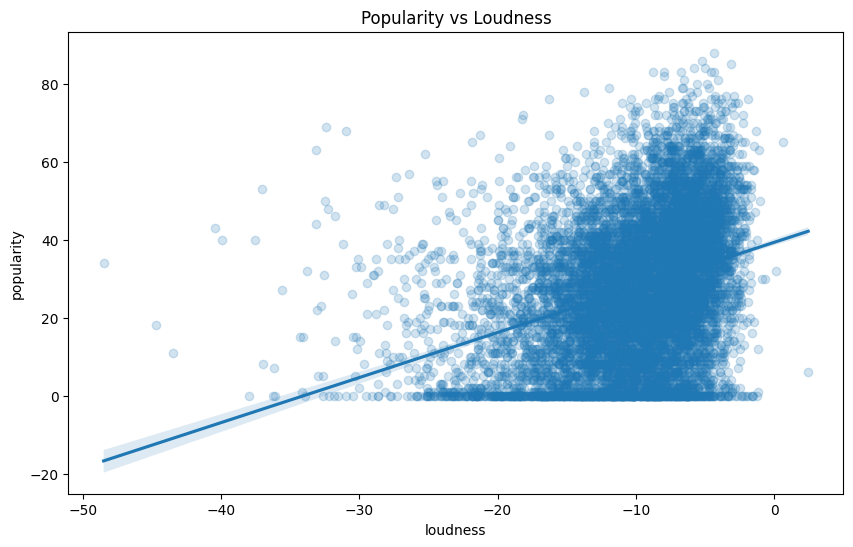

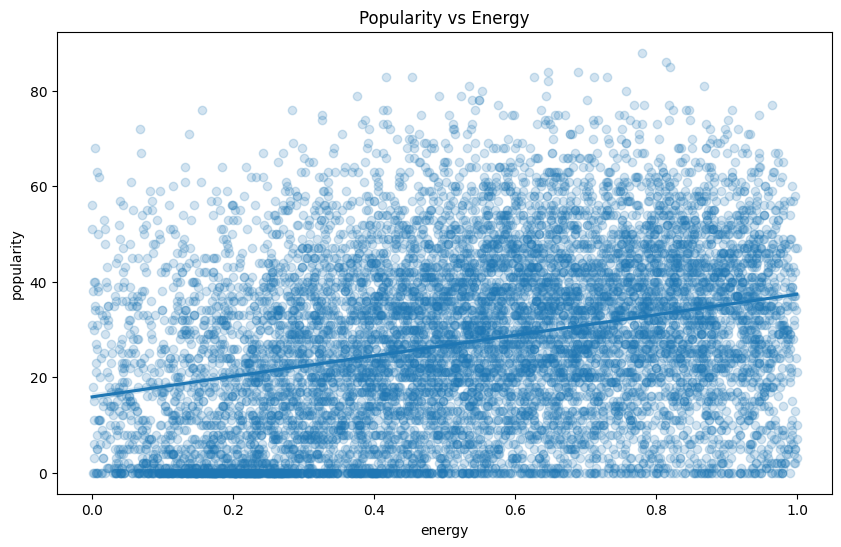

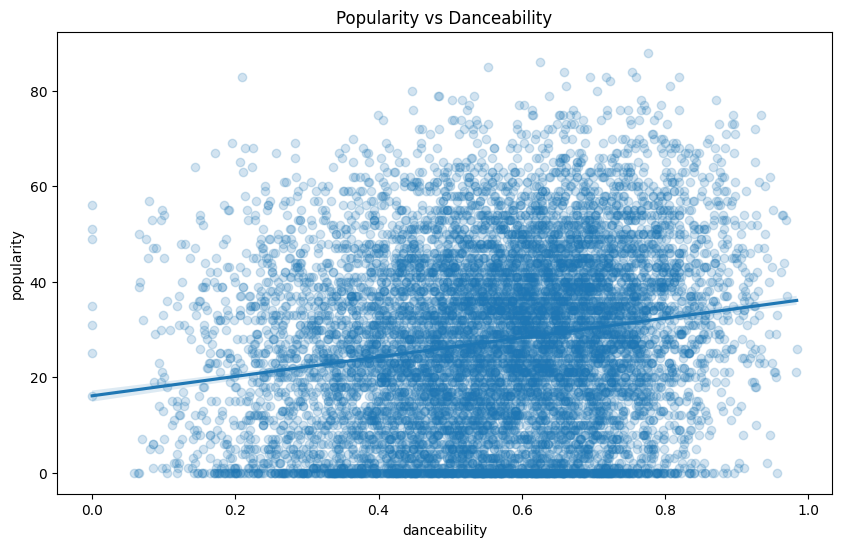

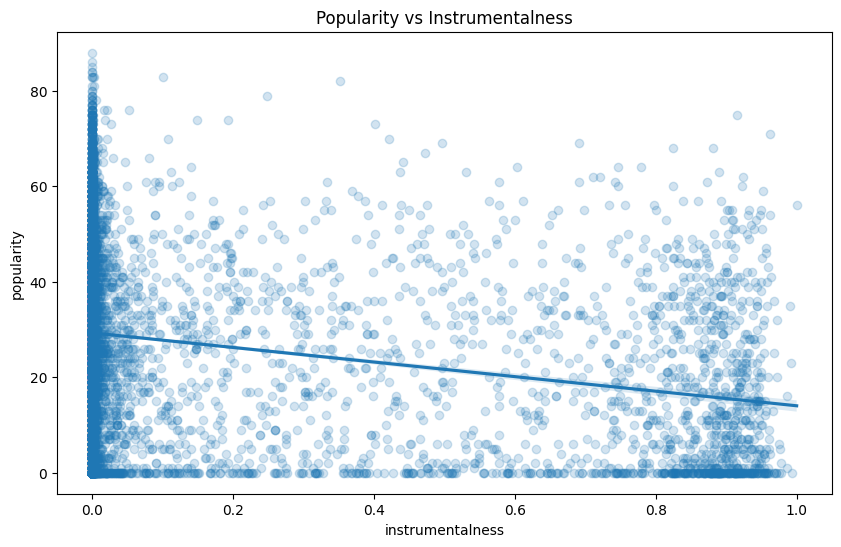

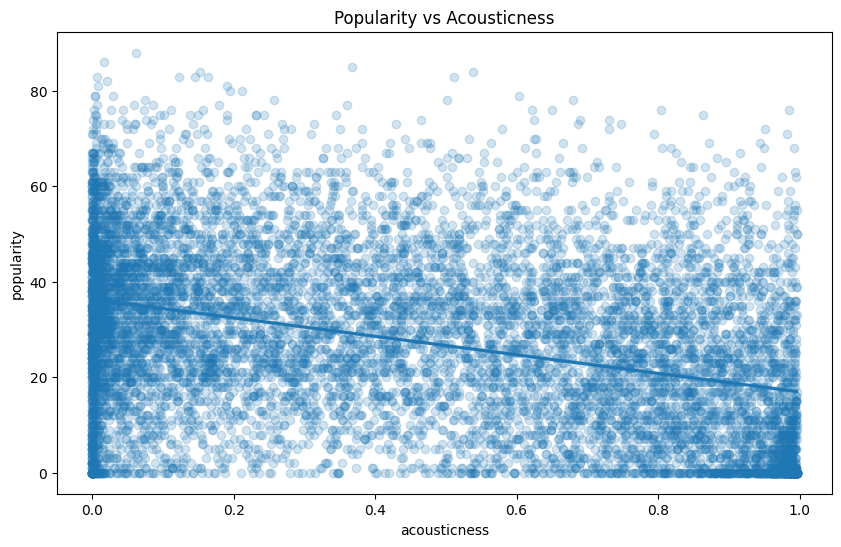

In [13]:
features = ["loudness", "energy", "danceability","instrumentalness" , "acousticness"]

for feature in features:
    plt.figure(figsize=(10,6))

    sns.regplot(
        data=sample_df,
        x=feature,
        y="popularity",
        scatter_kws={"alpha":0.2}
    )

    plt.title(f"Popularity vs {feature.capitalize()}")

    plt.show()

## Hit Songs vs Flop Songs

To better understand what differentiates successful tracks, songs are divided into:

- Hits (Popularity ≥ 70)
- Flops (Popularity ≤ 20)

Average feature values are then compared.

In [14]:
hits = model_df[model_df["popularity"] >= 70]

flops = model_df[model_df["popularity"] <= 20]

In [15]:
print("Hits:", len(hits))
print("Flops:", len(flops))

Hits: 7323
Flops: 219988


In [16]:
comparison = pd.DataFrame({
    "Hits": hits.mean(),
    "Flops": flops.mean()
})

comparison

,Hits,Flops
popularity,74.580636,8.477212
danceability,0.650059,0.531114
energy,0.642925,0.453141
loudness,-6.703224,-11.939921
speechiness,0.100435,0.108377
acousticness,0.246133,0.600731
instrumentalness,0.023650,0.187713
liveness,0.174324,0.219207
valence,0.520668,0.545633
tempo,121.890716,116.123857


## Key Findings

Comparing highly popular songs (popularity ≥ 70) with unpopular songs (popularity ≤ 20) revealed several clear differences:

- Hit songs are significantly less acoustic.
- Hit songs are louder and more energetic.
- Hit songs are more danceable.
- Hit songs contain much less instrumental content.
- Tempo shows only a minor difference.
- Song duration appears to have little impact on popularity.

These findings suggest that modern popular music tends to favor energetic, vocal-driven, and highly produced tracks.


# Popularity Prediction Models

The next phase of the project focuses on predicting song popularity using machine learning models.

Several approaches are compared to evaluate how well audio features explain popularity.

## Linear Regression

Linear Regression was used as a baseline model to evaluate the relationship between audio features and popularity.

Feature scaling was also tested using StandardScaler to determine whether normalization improved performance.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [18]:
X = model_df.drop("popularity", axis=1)

y = model_df["popularity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 2.59, 0.08, 0.62,...,-8.17,-0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['danceability','energy','loudness',...,'valence','tempo','duration_ms']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,46.07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [20]:
predictions = linear_model.predict(X_test)

In [21]:
print("MAE:", mean_absolute_error(y_test, predictions))
print("R²:", r2_score(y_test, predictions))

MAE: 13.30968132601518
R²: 0.19543409591381422


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
scaled_model = LinearRegression()

scaled_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 3.03, 0.62, 2.54,...,-3.7 , 0.25, 0.07]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,27.57
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1166.8 , 845. , 744.54,..., 457.46, 431.41, 251.72]"


In [25]:
scaled_predictions = scaled_model.predict(X_test_scaled)

In [26]:
print("MAE:", mean_absolute_error(y_test, scaled_predictions))
print("R²:", r2_score(y_test, scaled_predictions))

MAE: 13.182562060267946
R²: 0.2085084507940066


### Linear Regression Results

| Model | MAE | R² |
|---------|---------|---------|
| Linear Regression | 13.31 | 0.195 |
| Scaled Linear Regression | 13.18 | 0.209 |

Applying StandardScaler resulted in a small improvement in performance. However, both models achieved relatively low R² scores, suggesting that audio features alone cannot fully explain song popularity.


## Random Forest Regression

Random Forest was used to capture non-linear relationships between audio features and popularity.

Unlike Linear Regression, Random Forest can model complex interactions between variables, making it well-suited for this problem.

In [27]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [28]:
rf_predictions = rf_model.predict(X_test)

In [29]:
print("MAE:", mean_absolute_error(y_test, rf_predictions))
print("R²:", r2_score(y_test, rf_predictions))

MAE: 11.306032113331101
R²: 0.3797997409348197


### Random Forest Results

The Random Forest model achieved:

- MAE ≈ 11.31
- R² ≈ 0.38

This represents a substantial improvement over Linear Regression, suggesting that the relationship between audio features and popularity is not purely linear.

## Feature Importance Analysis

Random Forest provides feature importance scores that indicate which audio characteristics contribute most to popularity predictions.

In [30]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

acousticness        0.229279
loudness            0.127971
duration_ms         0.098562
valence             0.090704
danceability        0.083487
speechiness         0.081243
tempo               0.077416
energy              0.072277
liveness            0.069669
instrumentalness    0.069391
dtype: float64

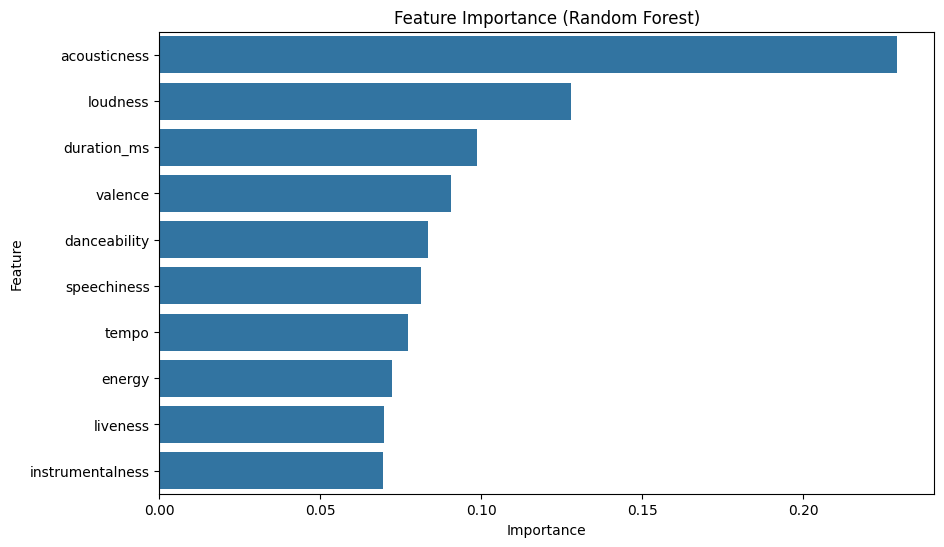

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Model Comparison

The performance of all models is compared using R² scores.

Higher R² values indicate better predictive capability.

In [32]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Scaled Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        13.3097,
        13.1826,
        11.3060
    ],
    "R2": [
        0.1954,
        0.2085,
        0.3800
    ]
})

results

,Model,MAE,R2
0,Linear Regression,13.3097,0.1954
1,Scaled Linear Regression,13.1826,0.2085
2,Random Forest,11.3060,0.3800


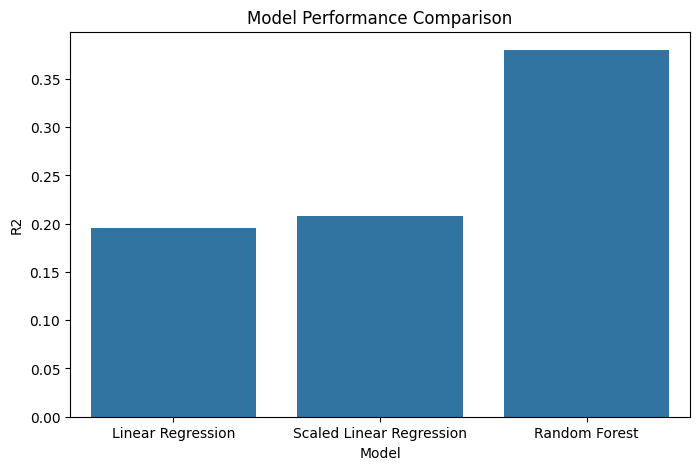

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title("Model Performance Comparison")

plt.show()

## Final Conclusion

Key findings from this project include:

- Louder songs tend to be more popular.
- Highly acoustic songs tend to be less popular.
- Danceability and energy show positive relationships with popularity.
- Audio features alone explain roughly 38% of popularity variation.
- Factors such as artist reputation, marketing, playlist placement, and cultural relevance likely explain the remaining variation.

The Random Forest model was selected as the final model due to its superior predictive performance.

## Model Export

The final Random Forest model is saved for deployment in a Streamlit application.

In [34]:
import joblib

joblib.dump(rf_model, "spotify_popularity_model.pkl")

['spotify_popularity_model.pkl']